In [1]:
# ─── CELL 1: mount & navigate ───────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Knowledge-Graph-Enhanced-RAG-for-Technical-Documents")
print("Working dir:", os.getcwd())

Mounted at /content/drive
Working dir: /content/drive/MyDrive/Knowledge-Graph-Enhanced-RAG-for-Technical-Documents


In [2]:
# ─── CELL 2: install ────────────────────────────────────────────────────
!pip install networkx sentence-transformers faiss-cpu \
             matplotlib pandas spacy requests -q
!python -m spacy download en_core_web_sm -q
print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 104.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Done.


In [3]:
# ─── CELL 3: reload all data and rebuild components ─────────────────────
# Must rerun since Colab session restarted
import pandas as pd
import numpy as np
import networkx as nx
import faiss
import spacy
from sentence_transformers import SentenceTransformer
from google.colab import userdata

# load data
df_docs     = pd.read_csv("data/processed/documents.csv")
df_qa       = pd.read_csv("data/processed/qa_pairs.csv")
df_entities = pd.read_csv("data/processed/entities.csv")
df_eval     = pd.read_csv("results/retrieval_results.csv")

# rebuild knowledge graph
from itertools import combinations
G = nx.Graph()
for _, row in df_entities.iterrows():
    G.add_node(row['text'], label=row['label'], doc_id=row['doc_id'])
for doc_id, group in df_entities.groupby('doc_id'):
    entities_in_doc = group['text'].tolist()
    for e1, e2 in combinations(entities_in_doc, 2):
        if G.has_edge(e1, e2):
            G[e1][e2]['weight'] += 1
        else:
            G.add_edge(e1, e2, weight=1, doc_id=doc_id)

# rebuild embeddings + FAISS
embedder   = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = np.load("data/processed/embeddings.npy")
dimension  = embeddings.shape[1]
index      = faiss.IndexFlatL2(dimension)
index.add(embeddings.astype('float32'))

# reload spaCy
nlp = spacy.load("en_core_web_sm")

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"FAISS: {index.ntotal} vectors")
print(f"Eval results: {len(df_eval)} rows")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Graph: 1254 nodes, 6240 edges
FAISS: 200 vectors
Eval results: 50 rows


In [4]:
# ─── CELL 4: retrieval functions (copied from notebook 2) ───────────────
def vector_rag_retrieve(question, top_k=3):
    q_embedding = embedder.encode([question]).astype('float32')
    distances, indices = index.search(q_embedding, top_k)
    retrieved = []
    for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        retrieved.append({
            'rank':     rank + 1,
            'doc_id':   int(df_docs.iloc[idx]['doc_id']),
            'text':     df_docs.iloc[idx]['text'],
            'distance': round(float(dist), 4)
        })
    return retrieved

def graph_rag_retrieve(question, top_k=3):
    doc = nlp(question)
    question_entities = [ent.text.strip() for ent in doc.ents]
    matched_nodes = []
    for qe in question_entities:
        for node in G.nodes():
            if qe.lower() in node.lower() or node.lower() in qe.lower():
                matched_nodes.append(node)
    expanded_nodes = set(matched_nodes)
    for node in matched_nodes:
        if node in G:
            neighbors = sorted(G.neighbors(node),
                               key=lambda n: G[node][n].get('weight',1),
                               reverse=True)[:5]
            expanded_nodes.update(neighbors)
    doc_ids = set()
    for node in expanded_nodes:
        if node in G.nodes():
            doc_ids.add(G.nodes[node].get('doc_id'))
    if not doc_ids:
        return vector_rag_retrieve(question, top_k), 'fallback'
    retrieved = []
    for doc_id in list(doc_ids)[:top_k]:
        if doc_id is not None:
            doc_row = df_docs[df_docs['doc_id'] == doc_id]
            if not doc_row.empty:
                retrieved.append({
                    'rank':    len(retrieved) + 1,
                    'doc_id':  doc_id,
                    'text':    doc_row.iloc[0]['text'],
                })
    return retrieved[:top_k], 'graph'

def is_correct(answer, context):
    answer  = str(answer).lower().strip()
    context = context.lower()
    if answer in context:
        return True
    words = [w for w in answer.split() if len(w) > 3]
    if len(words) == 0:
        return answer in context
    matches = sum(1 for w in words if w in context)
    return matches / len(words) >= 0.7

print("Functions loaded.")

Functions loaded.


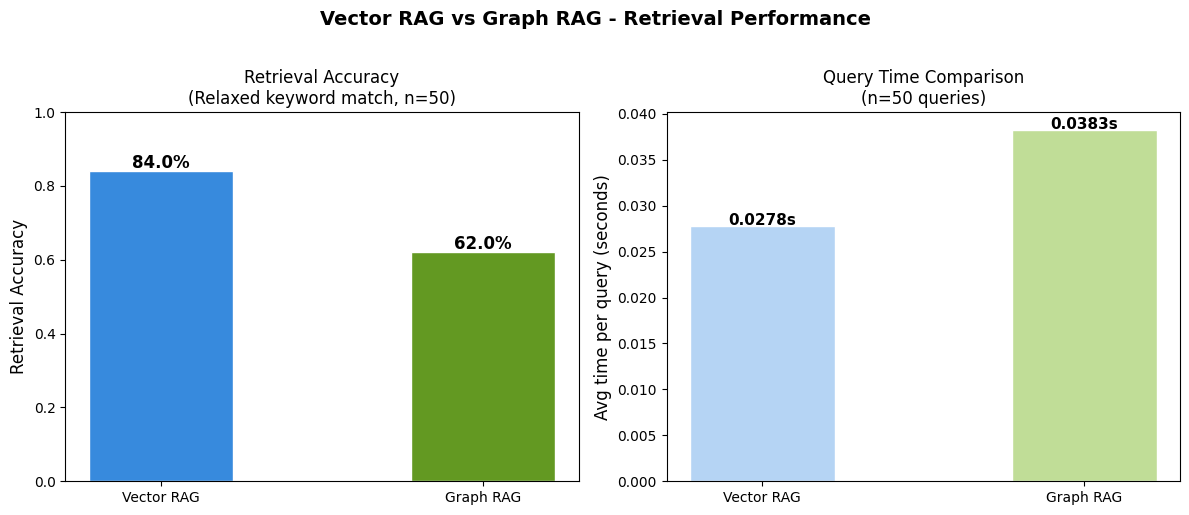

Saved.


In [6]:
# ─── CELL 5: plot 1 — accuracy comparison ───────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# plot A — relaxed accuracy
methods = ['Vector RAG', 'Graph RAG']
scores  = [df_eval['vector_correct'].mean(),
           df_eval['graph_correct'].mean()]
colors  = ['#378ADD', '#639922']

bars = axes[0].bar(methods, scores, color=colors,
                   width=0.45, edgecolor='white')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Retrieval Accuracy", fontsize=12)
axes[0].set_title("Retrieval Accuracy\n(Relaxed keyword match, n=50)", fontsize=12)
for bar, s in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 s + 0.01, f"{s:.1%}",
                 ha='center', fontsize=12, fontweight='bold')

# plot B — runtime
times = [df_eval['vector_time'].mean(),
         df_eval['graph_time'].mean()]
bars2 = axes[1].bar(methods, times, color=['#B5D4F4','#C0DD97'],
                    width=0.45, edgecolor='white')
axes[1].set_ylabel("Avg time per query (seconds)", fontsize=12)
axes[1].set_title("Query Time Comparison\n(n=50 queries)", fontsize=12)
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 t + 0.0001, f"{t:.4f}s",
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle("Vector RAG vs Graph RAG - Retrieval Performance",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results/figures/retrieval_comparison.png", dpi=150)
plt.show()
print("Saved.")

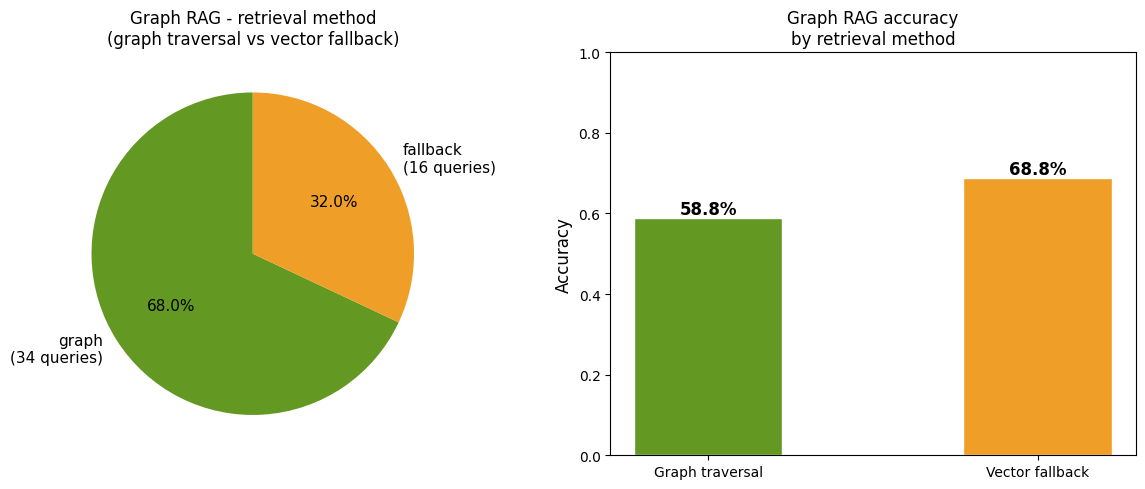

Saved.


In [7]:
# ─── CELL 6: plot 2 - graph RAG fallback analysis ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# pie — graph method distribution
method_counts = df_eval['graph_method'].value_counts()
axes[0].pie(method_counts.values,
            labels=[f"{k}\n({v} queries)" for k, v in method_counts.items()],
            colors=['#639922','#EF9F27'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title("Graph RAG - retrieval method\n(graph traversal vs vector fallback)",
                  fontsize=12)

# bar — accuracy by method type
graph_only    = df_eval[df_eval['graph_method'] == 'graph']['graph_correct'].mean()
fallback_only = df_eval[df_eval['graph_method'] == 'fallback']['graph_correct'].mean()

axes[1].bar(['Graph traversal', 'Vector fallback'],
            [graph_only, fallback_only],
            color=['#639922','#EF9F27'],
            width=0.45, edgecolor='white')
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("Graph RAG accuracy\nby retrieval method", fontsize=12)
for i, v in enumerate([graph_only, fallback_only]):
    axes[1].text(i, v + 0.01, f"{v:.1%}",
                 ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("results/figures/graph_fallback_analysis.png", dpi=150)
plt.show()
print("Saved.")

Both correct:    30
Vector RAG only: 12
Graph RAG only:  1
Both wrong:      7


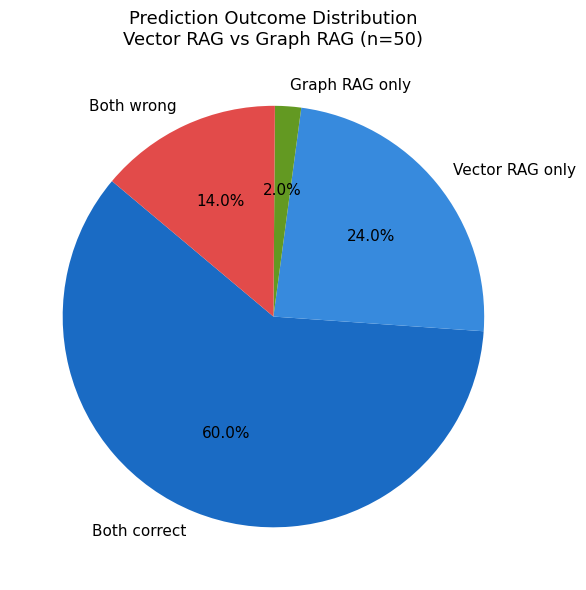

In [8]:
# ─── CELL 7: plot 3 — outcome distribution ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

both_correct   = len(df_eval[(df_eval['vector_correct']==True)  & (df_eval['graph_correct']==True)])
vector_only    = len(df_eval[(df_eval['vector_correct']==True)  & (df_eval['graph_correct']==False)])
graph_only_win = len(df_eval[(df_eval['vector_correct']==False) & (df_eval['graph_correct']==True)])
both_wrong     = len(df_eval[(df_eval['vector_correct']==False) & (df_eval['graph_correct']==False)])

labels = ['Both correct', 'Vector RAG only', 'Graph RAG only', 'Both wrong']
sizes  = [both_correct, vector_only, graph_only_win, both_wrong]
colors = ['#1A6BC4','#378ADD','#639922','#E24B4A']

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 11})
ax.set_title("Prediction Outcome Distribution\nVector RAG vs Graph RAG (n=50)",
             fontsize=13)

print(f"Both correct:    {both_correct}")
print(f"Vector RAG only: {vector_only}")
print(f"Graph RAG only:  {graph_only_win}")
print(f"Both wrong:      {both_wrong}")

plt.tight_layout()
plt.savefig("results/figures/outcome_distribution.png", dpi=150)
plt.show()

In [19]:
# ─── CELL 8: LLM via Groq API ──────────────────────────────
!pip install groq -q

from groq import Groq
from google.colab import userdata

GROQ_TOKEN = userdata.get('GROQ_TOKEN')
client     = Groq(api_key=GROQ_TOKEN)

def generate_answer_with_llm(question, context, max_tokens=200):
    """Generate answer using Groq free API — llama3 8B."""
    try:
        prompt = f"""Use the following context to answer the question.
Be concise and answer in 1-2 sentences only.

Context: {context[:800]}

Question: {question}"""

        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",   # updated model name
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_tokens,
            temperature=0.1
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"

# test
test_q = df_qa.iloc[0]['question']
v_docs = vector_rag_retrieve(test_q, top_k=2)
v_ctx  = " ".join([d['text'] for d in v_docs])
answer = generate_answer_with_llm(test_q, v_ctx)

print(f"Question: {test_q}")
print(f"GT: {df_qa.iloc[0]['answer'][:200]}")
print(f"LLM answer: {answer}")

Question: What is the Berry Export Summary 2028 and what is its purpose?
GT: The Berry Export Summary 2028 is a dedicated export plan for the Australian strawberry, raspberry, and blackberry industries. It maps the sectors’ current position, where they want to be, high-opportu
LLM answer: The Berry Export Summary 2028 is a dedicated export plan that maps the current position and future goals of the Australian strawberry, raspberry, and blackberry industries. Its purpose is to grow the global presence of these sectors over the next 10 years.


In [20]:
# ─── CELL 9: end-to-end RAG pipeline on 20 samples ──────────────────────
# Full pipeline: retrieve → generate → evaluate
# Using 20 samples only to stay within Groq free API rate limits
import time

pipeline_results = []
eval_sample = df_qa.head(20)

for i, row in eval_sample.iterrows():
    question = row['question']
    gt       = str(row['answer'])

    # vector RAG — retrieve + generate
    t0     = time.perf_counter()
    v_docs = vector_rag_retrieve(question, top_k=2)
    v_ctx  = " ".join([d['text'] for d in v_docs])
    v_ans  = generate_answer_with_llm(question, v_ctx)
    v_time = time.perf_counter() - t0

    # graph RAG — retrieve + generate
    t0     = time.perf_counter()
    g_docs, g_method = graph_rag_retrieve(question, top_k=2)
    g_ctx  = " ".join([d['text'] for d in g_docs])
    g_ans  = generate_answer_with_llm(question, g_ctx)
    g_time = time.perf_counter() - t0

    # evaluate
    v_correct = is_correct(gt, v_ans)
    g_correct = is_correct(gt, g_ans)

    pipeline_results.append({
        'id':             row['id'],
        'question':       question,
        'ground_truth':   gt,
        'vector_answer':  v_ans,
        'graph_answer':   g_ans,
        'vector_correct': v_correct,
        'graph_correct':  g_correct,
        'graph_method':   g_method,
        'vector_time':    round(v_time, 3),
        'graph_time':     round(g_time, 3),
    })

    print(f"Done {i+1}/20 — V:{v_correct} G:{g_correct} | '{v_ans[:60]}...'")
    time.sleep(1)   # respect Groq rate limit

df_pipeline = pd.DataFrame(pipeline_results)
df_pipeline.to_csv("results/pipeline_results.csv", index=False)

print("\n=== END-TO-END PIPELINE RESULTS ===")
print(f"Vector RAG + LLM accuracy: {df_pipeline['vector_correct'].mean():.1%}")
print(f"Graph RAG  + LLM accuracy: {df_pipeline['graph_correct'].mean():.1%}")
print(f"Avg Vector pipeline time:  {df_pipeline['vector_time'].mean():.2f}s")
print(f"Avg Graph  pipeline time:  {df_pipeline['graph_time'].mean():.2f}s")

Done 1/20 — V:False G:True | 'The Berry Export Summary 2028 is a dedicated export plan tha...'
Done 2/20 — V:True G:True | 'Benefits reported from having access to Self-supply water so...'
Done 3/20 — V:False G:False | 'The unique features of the Coolands for Twitter app are Real...'
Done 4/20 — V:False G:False | 'The main difference between the National Sample Survey (NSS)...'
Done 5/20 — V:False G:False | 'Gunnar Nelson won the fight against Zak Cummings at UFC Figh...'
Done 6/20 — V:False G:False | 'Fabiana Filippi's shirts and blouses feature timeless style,...'
Done 7/20 — V:False G:False | 'Dan Foley felt that his portrayal on the Survivor TV show wa...'
Done 8/20 — V:False G:False | 'Kim and Tony plan to have The New York Times' Green Garlic T...'
Done 9/20 — V:False G:False | 'There is no mention of a comments section being closed in th...'
Done 10/20 — V:False G:False | 'Unfortunately, the context does not mention the names of the...'
Done 11/20 — V:False G:False | 'Unfortunat

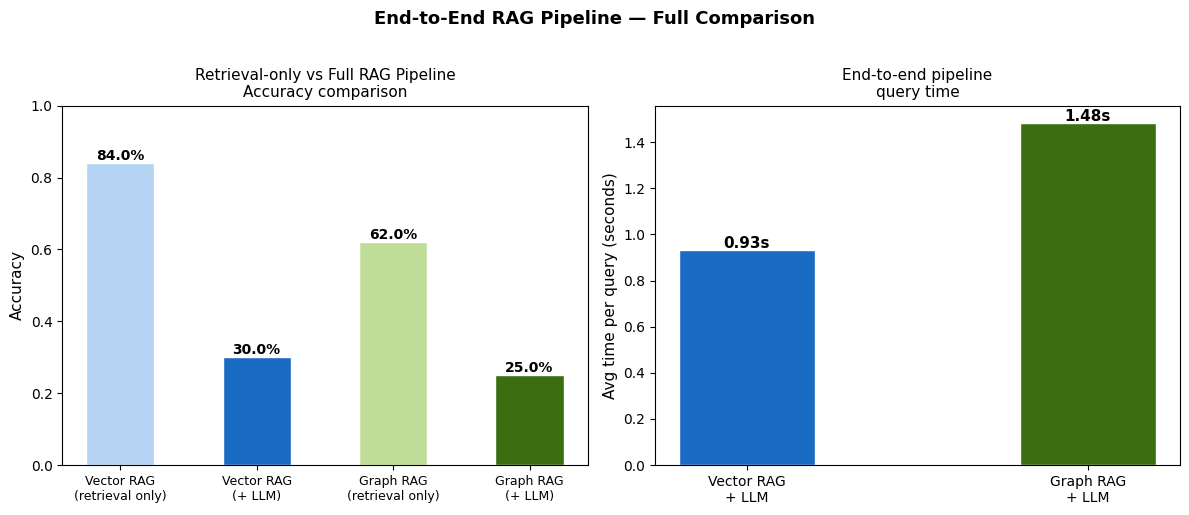

Saved.


In [21]:
# ─── CELL 10: plot 4 — end-to-end pipeline comparison ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# retrieval only vs full pipeline accuracy
methods  = ['Vector RAG\n(retrieval only)',
            'Vector RAG\n(+ LLM)',
            'Graph RAG\n(retrieval only)',
            'Graph RAG\n(+ LLM)']
scores   = [df_eval['vector_correct'].mean(),
            df_pipeline['vector_correct'].mean(),
            df_eval['graph_correct'].mean(),
            df_pipeline['graph_correct'].mean()]
colors   = ['#B5D4F4','#1A6BC4','#C0DD97','#3B6D11']

bars = axes[0].bar(methods, scores, color=colors,
                   width=0.5, edgecolor='white')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Accuracy", fontsize=11)
axes[0].set_title("Retrieval-only vs Full RAG Pipeline\nAccuracy comparison",
                  fontsize=11)
axes[0].tick_params(axis='x', labelsize=9)
for bar, s in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 s + 0.01, f"{s:.1%}",
                 ha='center', fontsize=10, fontweight='bold')

# pipeline runtime
p_times  = [df_pipeline['vector_time'].mean(),
            df_pipeline['graph_time'].mean()]
axes[1].bar(['Vector RAG\n+ LLM', 'Graph RAG\n+ LLM'],
            p_times, color=['#1A6BC4','#3B6D11'],
            width=0.4, edgecolor='white')
axes[1].set_ylabel("Avg time per query (seconds)", fontsize=11)
axes[1].set_title("End-to-end pipeline\nquery time", fontsize=11)
for i, t in enumerate(p_times):
    axes[1].text(i, t + 0.01, f"{t:.2f}s",
                 ha='center', fontsize=11, fontweight='bold')

plt.suptitle("End-to-End RAG Pipeline — Full Comparison",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results/figures/pipeline_comparison.png", dpi=150)
plt.show()
print("Saved.")

In [22]:
# ─── CELL 11: print sample answers for README ────────────────────────────
print("=== SAMPLE PIPELINE OUTPUTS ===\n")
for _, row in df_pipeline.head(3).iterrows():
    print(f"Q:  {row['question']}")
    print(f"GT: {row['ground_truth'][:150]}")
    print(f"Vector RAG answer: {row['vector_answer'][:150]}")
    print(f"Graph RAG answer:  {row['graph_answer'][:150]}")
    print(f"Vector correct: {row['vector_correct']} | Graph correct: {row['graph_correct']}")
    print("---")

=== SAMPLE PIPELINE OUTPUTS ===

Q:  What is the Berry Export Summary 2028 and what is its purpose?
GT: The Berry Export Summary 2028 is a dedicated export plan for the Australian strawberry, raspberry, and blackberry industries. It maps the sectors’ cur
Vector RAG answer: The Berry Export Summary 2028 is a dedicated export plan that maps the current position and future goals of the Australian strawberry, raspberry, and 
Graph RAG answer:  The Berry Export Summary 2028 is a dedicated export plan that maps the current position, desired future, high-opportunity markets, and next steps for 
Vector correct: False | Graph correct: True
---
Q:  What are some of the benefits reported from having access to Self-supply water sources?
GT: Benefits reported from having access to Self-supply water sources include convenience, less time spent for fetching water and access to more and bette
Vector RAG answer: Benefits reported from having access to Self-supply water sources include convenience, less

In [23]:
# ─── CELL 12: save final summary ─────────────────────────────────────────
summary = {
    'method': [
        'Vector RAG (retrieval only)',
        'Graph RAG (retrieval only)',
        'Vector RAG + LLM',
        'Graph RAG + LLM'
    ],
    'accuracy': [
        round(df_eval['vector_correct'].mean(), 3),
        round(df_eval['graph_correct'].mean(), 3),
        round(df_pipeline['vector_correct'].mean(), 3),
        round(df_pipeline['graph_correct'].mean(), 3),
    ],
    'avg_time_sec': [
        round(df_eval['vector_time'].mean(), 4),
        round(df_eval['graph_time'].mean(), 4),
        round(df_pipeline['vector_time'].mean(), 3),
        round(df_pipeline['graph_time'].mean(), 3),
    ]
}
pd.DataFrame(summary).to_csv("results/final_summary.csv", index=False)
print(pd.DataFrame(summary).to_string())

                        method  accuracy  avg_time_sec
0  Vector RAG (retrieval only)      0.84        0.0278
1   Graph RAG (retrieval only)      0.62        0.0383
2             Vector RAG + LLM      0.30        0.9330
3              Graph RAG + LLM      0.25        1.4840
